In [ ]:
# ===== Importing Libraries =====


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

import plotly.express as px
import plotly.graph_objects as go

from data_loader import load_data

In [ ]:
# ===== Loading Dataset =====

vertebral_column = load_data('../data/vertebral_column.csv')
vertebral_column.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,is_abnormal
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1


In [ ]:
# ===== Summary Statistics =====

vertebral_column.describe()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,is_abnormal
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694,0.677419
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027,0.468220
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179,0.000000
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727,0.000000
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934,1.000000
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352,1.000000
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082,1.000000


In [ ]:
# ===== Shape of the dataset =====
vertebral_column.shape

(310, 7)

In [ ]:
# ===== Infornamtion on the dataset =====
vertebral_column.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   is_abnormal               310 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 17.1 KB


In [ ]:
# ===== Checking For Missing Values =====

def missing_values(data):
    values = data.isnull().sum().sort_values(ascending=False)

    print(values)

missing_values(vertebral_column)

pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
is_abnormal                 0
dtype: int64


In [ ]:
# ===== Checking For Outliers =====

def check_outliers(data):
    q1 = data.select_dtypes(include=['number']).quantile(0.25)
    q3 = data.select_dtypes(include=['number']).quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return lower_bound, upper_bound

lower_bound, upper_bound = check_outliers(vertebral_column)

In [ ]:
def outliers(data, lower_bound, upper_bound):
    for cols in data.select_dtypes(include=['number']):
        mask = (lower_bound[cols] < data[cols]) | (upper_bound[cols] > data[cols])
        counts = mask.sum()
        if counts > 0:
            print(
                f'{cols} : {counts} outliers | ',
                f'bound = [{lower_bound[cols]:.3f}, {upper_bound[cols]:.3f}] | ',
                f'actual min = {data[cols].min():.3f}, actual max = {data[cols].max():.3f}'
            )

print(outliers(vertebral_column, lower_bound, upper_bound))

pelvic_incidence : 310 outliers |  bound = [6.759, 112.549] |  actual min = 26.148, actual max = 129.834
pelvic_tilt : 310 outliers |  bound = [-6.513, 39.300] |  actual min = -6.555, actual max = 49.432
lumbar_lordosis_angle : 310 outliers |  bound = [-2.000, 102.000] |  actual min = 14.000, actual max = 125.742
sacral_slope : 310 outliers |  bound = [4.324, 81.719] |  actual min = 13.367, actual max = 121.430
pelvic_radius : 310 outliers |  bound = [88.571, 147.605] |  actual min = 70.083, actual max = 163.071
degree_spondylolisthesis : 310 outliers |  bound = [-57.922, 100.813] |  actual min = -11.058, actual max = 418.543
is_abnormal : 310 outliers |  bound = [-1.500, 2.500] |  actual min = 0.000, actual max = 1.000
None


In [ ]:
# ===== Plotting Outliers =====

def plot_outliers(data):
    plt.figure(figsize=(22, 6))
    figure = px.box(data.select_dtypes(include=['number']),
                    orientation='h',
                     title= 'Outliers Visualization')
    
    figure.show()
    plt.show()

plot_outliers(vertebral_column)

<Figure size 2200x600 with 0 Axes>

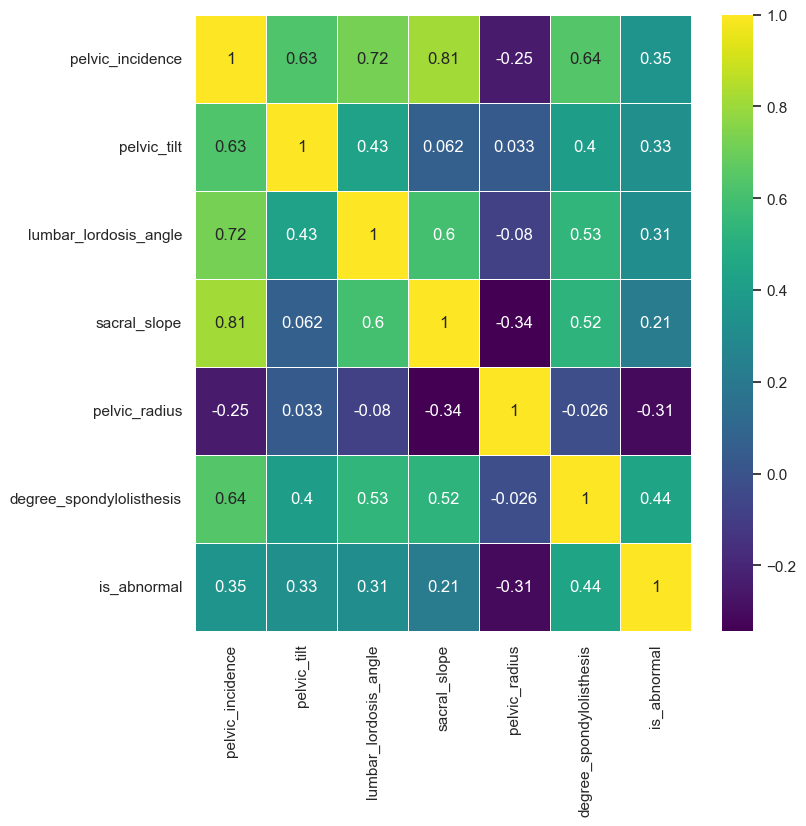

In [ ]:
# ===== Correlation HeatMap =====

def plot_correlation(data):
    corr_matrix = data.select_dtypes(include=['number']).corr()

    plt.figure(figsize=(8, 8))
    sns.heatmap(corr_matrix,
                annot=True, 
                linewidths=0.5, cmap='viridis')
    plt.show()

plot_correlation(vertebral_column)

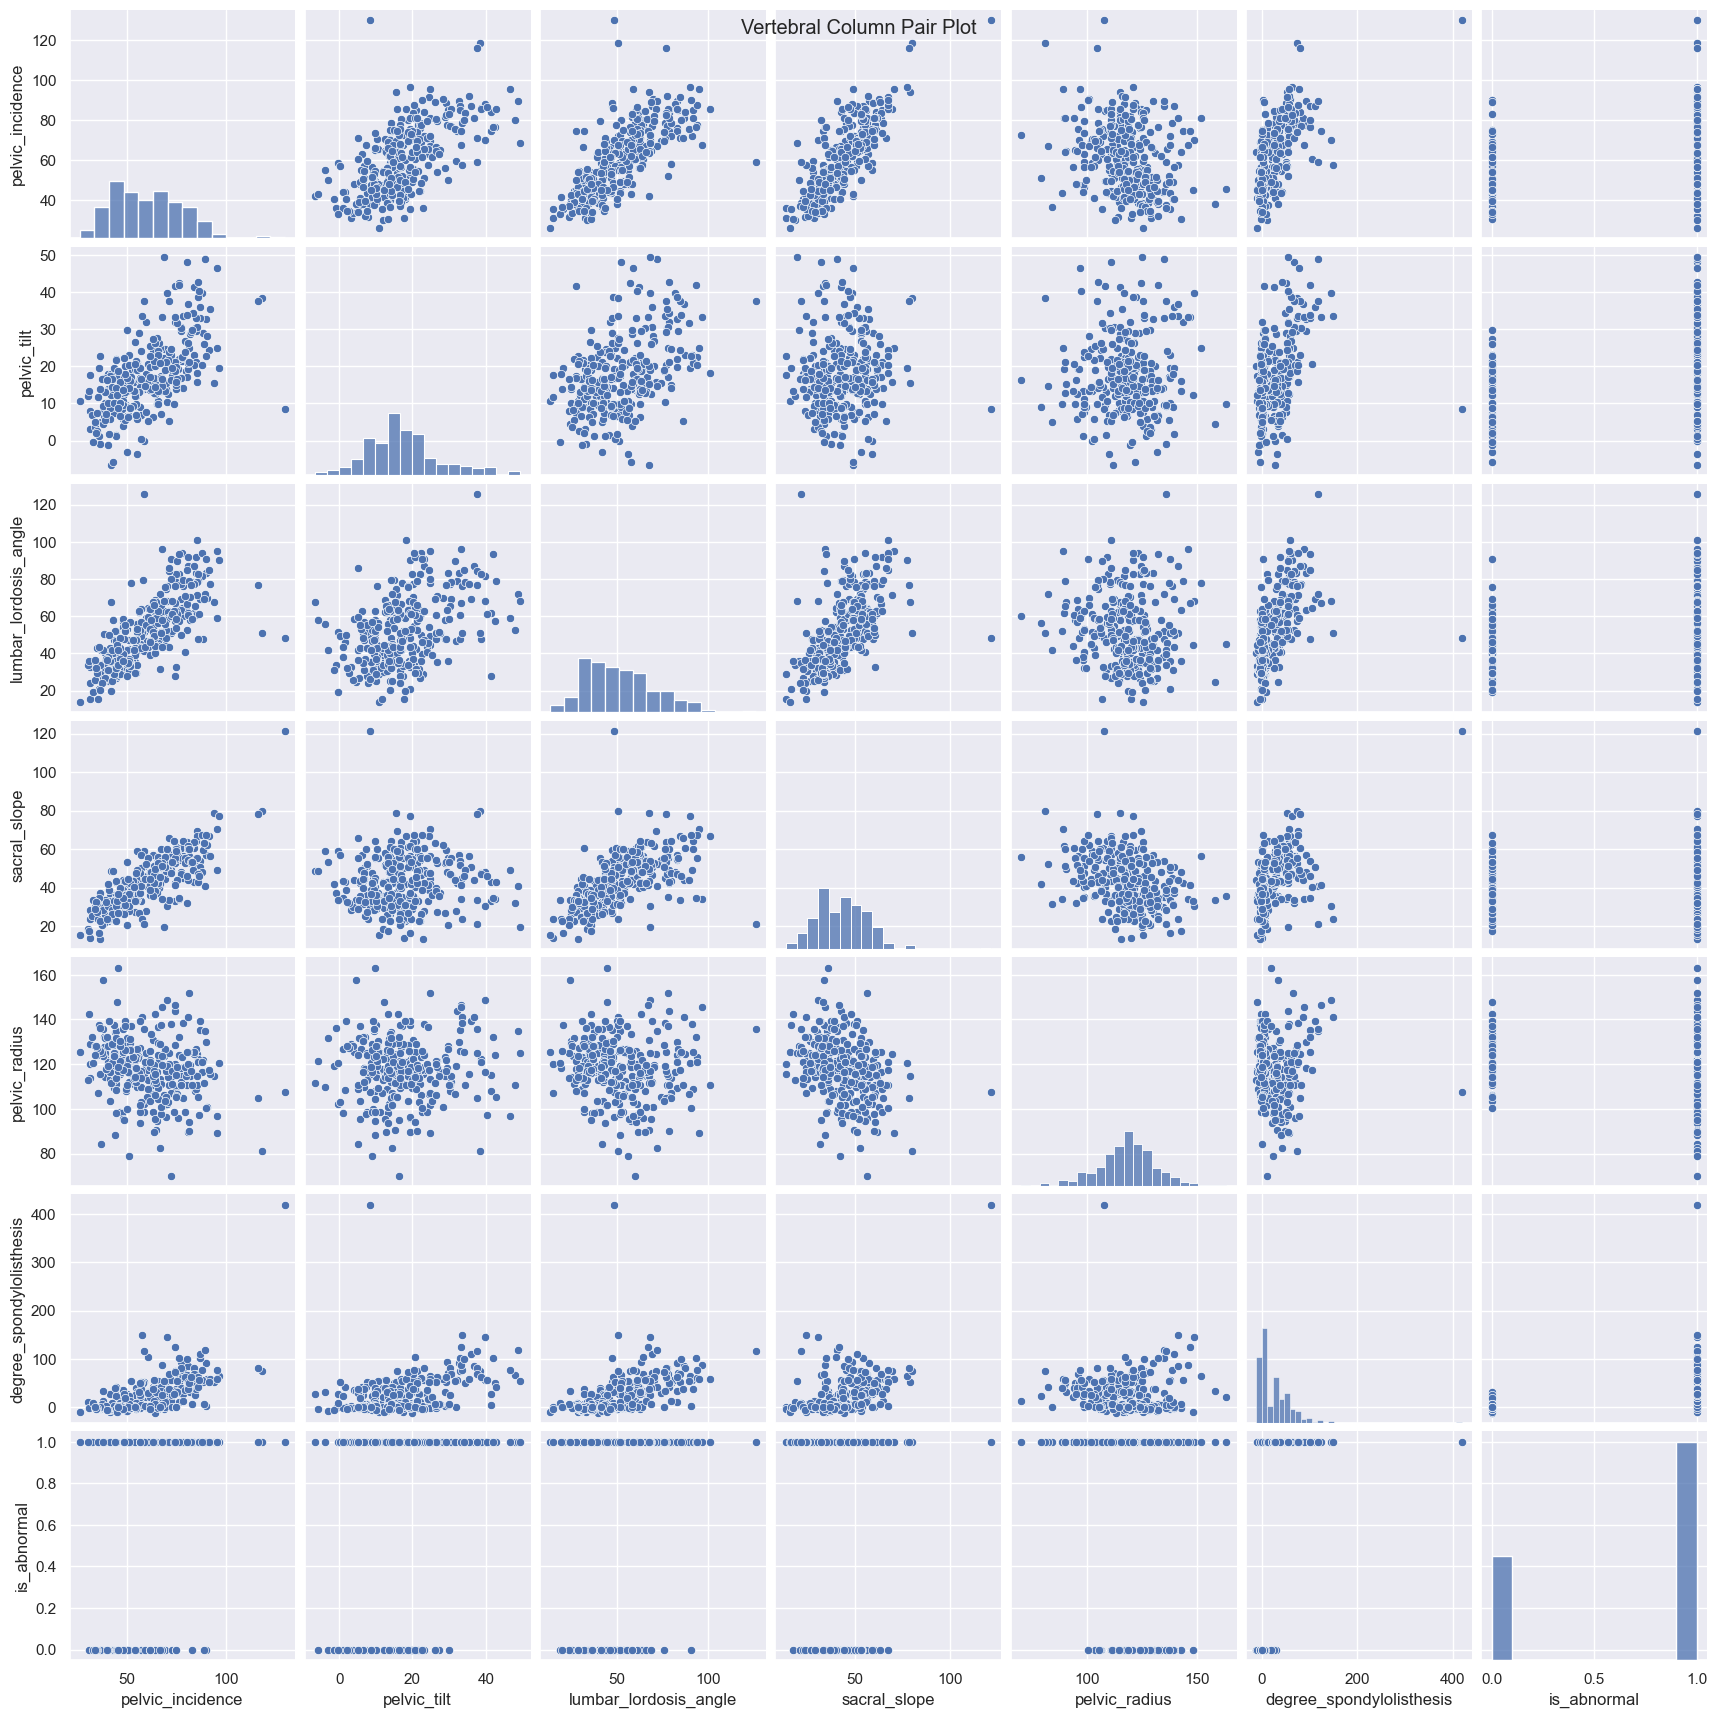

In [ ]:
# ===== Pair Plot =====

def plot_pairplot(data):
    sns.pairplot(data.select_dtypes(include=['number']))
    plt.suptitle('Vertebral Column Pair Plot')
    plt.show()

plot_pairplot(vertebral_column)